<a href="https://colab.research.google.com/github/CharalapML/ML_Tests/blob/main/61_NN_Sequential_Multiple_Attributes_18_09_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive
drive.mount('/content/gdrive')
!ls "/content/gdrive/My Drive"

Mounted at /content/gdrive
 CNN_TestData
'Colab Notebooks'
 data_request_2018-09-01_2018-09-05_obspyDMT_data_II-IU-IC-G-GE-GT_simple
 event_list_pickle.txt
'Getting started.pdf'
 inf-openflights
'Initial Document on CFs for Kurtosis .gdoc'
 ISC_RAWFILES
 ISC_RAWFILES_2ndTranche
'readme copy.html'


In [ ]:
import tensorflow as tf
from tensorflow import keras

from keras.layers import Dense, Activation, Flatten

from tensorflow.keras import datasets, layers, models
from keras.layers import UpSampling3D, Conv3DTranspose, Conv3D, MaxPooling3D
from tensorflow.nn import conv3d_transpose

from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#INPUT_4D_DATASET_Xa = np.load("/content/gdrive/My Drive/CNN_TestData/4Darray_1_Unordered_in.npy",  mmap_mode=None, allow_pickle=False, fix_imports=True, encoding='ASCII')
#RESULT4D_DATASET_ya = np.load("/content/gdrive/My Drive/CNN_TestData/4Darray_1_Unordered_out.npy", mmap_mode=None, allow_pickle=False, fix_imports=True, encoding='ASCII')

INPUT_4D_DATASET_Xa = np.load("/content/gdrive/My Drive/CNN_TestData/4Darray_2_Ordered_in.npy",  mmap_mode=None, allow_pickle=False, fix_imports=True, encoding='ASCII')
RESULT4D_DATASET_ya = np.load("/content/gdrive/My Drive/CNN_TestData/4Darray_2_Ordered_out.npy", mmap_mode=None, allow_pickle=False, fix_imports=True, encoding='ASCII')

print("INPUT_4D_DATASET_Xa NaNs   = ", np.count_nonzero(np.isnan(INPUT_4D_DATASET_Xa)) )
print("RESULT4D_DATASET_ya NaNs   = ", np.count_nonzero(np.isnan(RESULT4D_DATASET_ya)) )
print('\n', "--------------------", '\n')
RESULT4D_DATASET_ya = np.nan_to_num(RESULT4D_DATASET_ya, copy=True, nan=0.0, posinf=None, neginf=None) # removes NaNs !!!

print("INPUT_4D_DATASET_Xa NaNs   = ", np.count_nonzero(np.isnan(INPUT_4D_DATASET_Xa)) )
print("RESULT4D_DATASET_ya NaNs   = ", np.count_nonzero(np.isnan(RESULT4D_DATASET_ya)) )

print("INPUT_4D_DATASET_Xa type   = ", type(INPUT_4D_DATASET_Xa))

print("INPUT_4D_DATASET_Xa length = ", len(INPUT_4D_DATASET_Xa))
print("INPUT_4D_DATASET_Xa.shape  = ", INPUT_4D_DATASET_Xa.shape)
print("INPUT_4D_DATASET_Xa size   = ", INPUT_4D_DATASET_Xa.size)
print('\n', "--------------------", '\n')
print("RESULT4D_DATASET_ya length = ", len(RESULT4D_DATASET_ya))
print("RESULT4D_DATASET_ya.shape  = ", RESULT4D_DATASET_ya.shape)
print("RESULT4D_DATASET_ya size   = ", RESULT4D_DATASET_ya.size)

INPUT_4D_DATASET_Xa NaNs   =  0
RESULT4D_DATASET_ya NaNs   =  16000

 -------------------- 

INPUT_4D_DATASET_Xa NaNs   =  0
RESULT4D_DATASET_ya NaNs   =  0
INPUT_4D_DATASET_Xa type   =  <class 'numpy.ndarray'>
INPUT_4D_DATASET_Xa length =  4
INPUT_4D_DATASET_Xa.shape  =  (4, 10, 5, 8000)
INPUT_4D_DATASET_Xa size   =  1600000

 -------------------- 

RESULT4D_DATASET_ya length =  4
RESULT4D_DATASET_ya.shape  =  (4, 10, 1, 8000)
RESULT4D_DATASET_ya size   =  320000


In [ ]:
print (INPUT_4D_DATASET_Xa.shape)

(4, 10, 5, 8000)


In [ ]:
#for x in INPUT_4D_DATASET_Xa[:,x,:,:]:

# need to normalise all traces in all inputs


In [ ]:
target_ys = []
for y in RESULT4D_DATASET_ya:# Note that numpy will by default use the 1st dimension to iterate through
    target_ys.append(y.reshape(80000))

In [ ]:
len(target_ys)
target_ys = np.array(target_ys)
target_ys.shape

(4, 80000)

In [ ]:
model = models.Sequential()
model.add(layers.Conv3D(32, (2, 1, 2), activation='relu', input_shape=(10, 5, 8000, 1), strides=(2,1,2)))
model.add(layers.MaxPooling3D((1, 2, 2)))
model.add(layers.Conv3D(64, (1, 1, 2), activation='relu', strides=(1,1,2)))
model.add(layers.MaxPooling3D((1, 2, 2)))
model.add(layers.Conv3D(64, (1, 1, 2), activation='relu', strides=(1,1,2)))
model.add(Flatten())
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d (Conv3D)             (None, 5, 5, 4000, 32)    160       
                                                                 
 max_pooling3d (MaxPooling3D  (None, 5, 2, 2000, 32)   0         
 )                                                               
                                                                 
 conv3d_1 (Conv3D)           (None, 5, 2, 1000, 64)    4160      
                                                                 
 max_pooling3d_1 (MaxPooling  (None, 5, 1, 500, 64)    0         
 3D)                                                             
                                                                 
 conv3d_2 (Conv3D)           (None, 5, 1, 250, 64)     8256      
                                                                 
 flatten (Flatten)           (None, 80000)             0

In [ ]:
for layer in model.layers:
    print(layer.output_shape)

(None, 5, 5, 4000, 32)
(None, 5, 2, 2000, 32)
(None, 5, 2, 1000, 64)
(None, 5, 1, 500, 64)
(None, 5, 1, 250, 64)
(None, 80000)


In [ ]:
model.layers[-1].output_shape

(None, 80000)

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])  # mse = mean sq error
history = model.fit(INPUT_4D_DATASET_Xa[:-1],target_ys[:-1], epochs=4, batch_size=1)

test_X = np.array([INPUT_4D_DATASET_Xa[-1]])
test_Y = np.array([target_ys[-1]])

model.evaluate(test_X,test_Y)


Epoch 1/4
3/3 [==============================] - 2s 447ms/step - loss: 0.0047 - accuracy: 0.0000e+00
Epoch 2/4
3/3 [==============================] - 1s 432ms/step - loss: 0.0035 - accuracy: 0.0000e+00
Epoch 3/4
3/3 [==============================] - 1s 438ms/step - loss: 0.0028 - accuracy: 0.0000e+00
Epoch 4/4
1/1 [==============================] - 0s 210ms/step - loss: 0.0020 - accuracy: 0.0000e+00


[0.002019632840529084, 0.0]

In [ ]:
print(history.history.keys())
print(history.history['loss'])

dict_keys(['loss', 'accuracy'])
[0.004732394590973854, 0.0034838521387428045, 0.0028358756098896265, 0.002539302920922637]


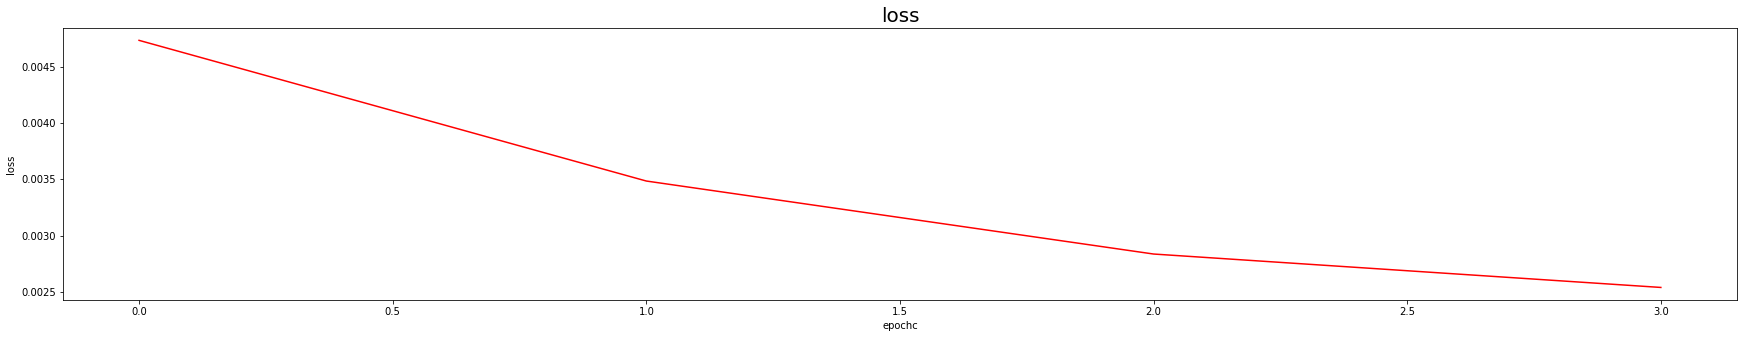

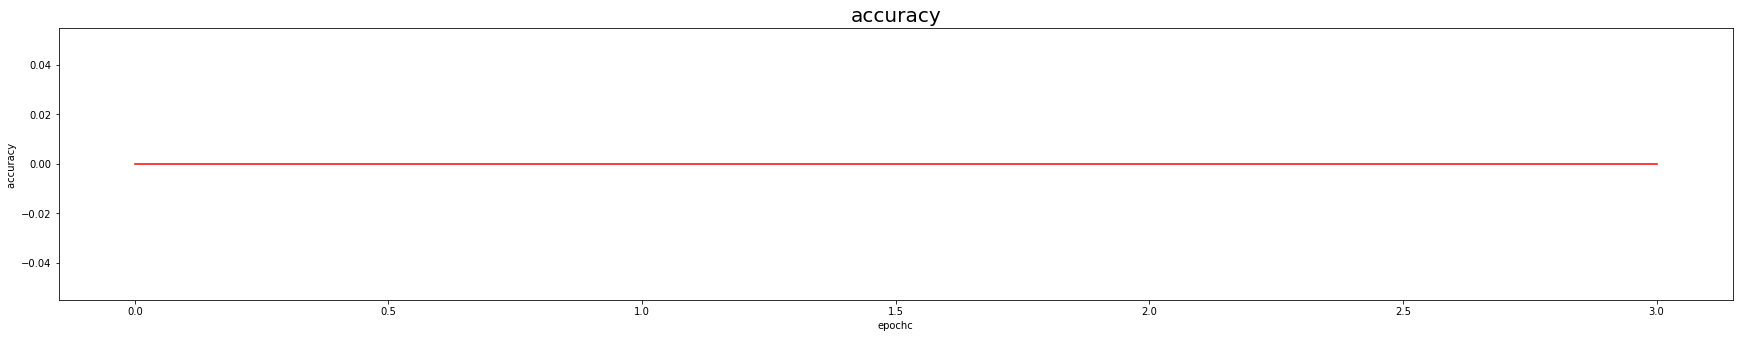

In [ ]:

plt.figure(figsize=(30,5))
#plt.ylim([-0.1, .1])
plt.plot(history.history['loss'], label='loss', color= 'red')
#plt.axhline(cepstrum_abs_mean*2)
plt.xlabel('epochc')
plt.ylabel('loss ')
plt.title("loss", size = 20)
plt.show()

plt.figure(figsize=(30,5))
#plt.ylim([-0.1, .1])
plt.plot(history.history['accuracy'], label='loss', color= 'red')
#plt.axhline(cepstrum_abs_mean*2)
plt.xlabel('epochc')
plt.ylabel('accuracy ')
plt.title("accuracy", size = 20)
plt.show()


To do a Grid search to find the 'best/ optiml' parameters
Test and compare different optimzers and loss functions

Plot the various optimisers against the various loss functions, BUT note it is probably best to use the accuaracy value to compare  each optimiser/loss function pairing

In [ ]:

optimizers = ['adam', 'nadam'] # 'nadam'
losses = ['mse', 'huber']      #  'huber'
#Accuracies =[2,1]
Accuracies =[]
for optimizer in optimizers:
  for loss in losses:
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
    model.fit(INPUT_4D_DATASET_Xa[:-1],target_ys[:-1], epochs=4, batch_size=1)
    #Accuracies[optimizers, losses] = history.history['accuracy']
    #Accuracies = np.hstack(history.history['accuracy'])
    Accuracies.append(history.history['accuracy'][-1])




Epoch 1/4
3/3 [==============================] - 2s 431ms/step - loss: 0.0024 - accuracy: 0.0000e+00
Epoch 2/4
3/3 [==============================] - 1s 442ms/step - loss: 0.0023 - accuracy: 0.0000e+00
Epoch 3/4
3/3 [==============================] - 1s 440ms/step - loss: 0.0023 - accuracy: 0.0000e+00
Epoch 4/4
3/3 [==============================] - 1s 430ms/step - loss: 0.0023 - accuracy: 0.0000e+00
Epoch 1/4
3/3 [==============================] - 2s 453ms/step - loss: 0.0011 - accuracy: 0.0000e+00
Epoch 2/4
3/3 [==============================] - 1s 434ms/step - loss: 0.0011 - accuracy: 0.0000e+00
Epoch 3/4
3/3 [==============================] - 1s 448ms/step - loss: 0.0011 - accuracy: 0.0000e+00
Epoch 4/4
3/3 [==============================] - 1s 434ms/step - loss: 0.0011 - accuracy: 0.0000e+00
Epoch 1/4
3/3 [==============================] - 2s 436ms/step - loss: 0.0022 - accuracy: 0.0000e+00
Epoch 2/4
3/3 [==============================] - 1s 435ms/step - loss: 0.0022 - accuracy: 0

In [ ]:
print (Accuracies)

[0.0, 0.0, 0.0, 0.0]


In [ ]:
pip install visualkeras

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 992 kB 4.6 MB/s 


In [ ]:
import visualkeras

In [ ]:
from collections import defaultdict
color_map = defaultdict(dict)                    #customize the colours
color_map[layers.Conv2D]['fill'] = '#00f5d4'
color_map[layers.MaxPooling2D]['fill'] = '#8338ec'
color_map[layers.Dropout]['fill'] = '#03045e'
color_map[layers.Dense]['fill'] = '#fb5607'
color_map[layers.Flatten]['fill'] = '#ffbe0b'

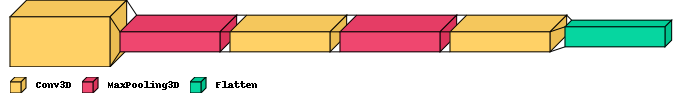

In [ ]:
visualkeras.layered_view(model, legend=True, scale_xy=10, scale_z=2, max_z=100) # without custom font
#from PIL import ImageFont, ImageDraw
##font = ImageFont.truetype("arial.ttf", 12)
##visualkeras.layered_view(model, legend=True, font=font) # selected font
#visualkeras.layered_view(model, legend=True, color_map=color_map) # no font

In [ ]:

reshape(model.layers[-1])

NameError: ignored

In [ ]:
npy.reshape(a, newshape, order='C')[source]